# Hydrogen Doppler-split demo

Visual verification of the two Doppler velocities introduced by task 009
(split of `Atmosphere.Vd` into `Vd_sun` and `Vd_obs`).

This notebook is **generated** from `build_notebook.py` in this folder.
Re-run the script after any change to the SE / Cloud / Atmosphere APIs.


## Physics & sign convention

We carry two distinct line-of-sight velocities for an atom:

- **$V_{\rm sun}$** — atom velocity in the **sun's rest frame**.
  *Sign convention:* $+V_{\rm sun}$ points **OUTWARDS** from the sun
  (atom receding from sun).
- **$V_{\rm obs}$** — atom velocity in the **observer's rest frame**.
  *Sign convention (astronomy radial-velocity):* $+V_{\rm obs}$ points
  **AWAY** from the observer (source receding from observer).

### Non-relativistic Doppler

Standard formula for a source emitting at $\lambda_{\rm src}$ as seen
by an observer with line-of-sight velocity $v$ relative to the source:

$$\lambda_{\rm obs} = \lambda_{\rm src}\,(1 + v_{\rm relative}/c),
\qquad v_{\rm relative} > 0 \Leftrightarrow \text{recession}.$$

### How $V_{\rm sun}$ enters the SE (statistical equilibrium) solver

The atom absorbs at its rest-frame line center $w_0$. The atom is
moving outward at $+V_{\rm sun}$, i.e. receding from the sun's
radiation source. From the atom's frame, the incoming solar
photon looks red-shifted:

$$\lambda_{\rm atom} = \lambda_{\rm sun}\,(1 + V_{\rm sun}/c).$$

Setting $\lambda_{\rm atom} = w_0$ gives the **sun-frame wavelength
that gets absorbed**:

$$\lambda_{\rm sun} = \frac{w_0}{1 + V_{\rm sun}/c}
                    \approx w_0 - \frac{w_0 V_{\rm sun}}{c}.$$

So in the **sun frame**, the absorption line center moves **blue** of
$w_0$ by $w_0 V_{\rm sun}/c$. SE integrates the line profile
$\sigma$ against `backRad` on the fixed sun-frame wavelength grid
$w_m^{\rm cm} = w_m\,\Delta\lambda_D + w_0$, so the profile sampled
on this grid evaluates to

$$\sigma_{\rm sun}(w_m^{\rm cm})
  = \sigma\!\left(\frac{w_m^{\rm cm} - (w_0 - w_0 V_{\rm sun}/c)}{\Delta\lambda_D}\right) \big/ \Delta\lambda_D
  = \sigma\!\left(w_m + dv_{\rm sun}\right) \big/ \Delta\lambda_D,$$

where $dv_{\rm sun} = w_0 V_{\rm sun} / (c\,\Delta\lambda_D)$ is the
shift in Doppler-width units. SELib evaluates **both** profiles:

- `absorb_prof_1d` = $\sigma(w_m) / \Delta\lambda_D$ — unshifted
  (canonical, atom rest frame).
- `absorb_prof_shifted_1d` = $\sigma(w_m + dv_{\rm sun}) / \Delta\lambda_D$
  — Vd_sun-shifted; this is what SE integrates for $J_{\rm bar}$.

### How $V_{\rm obs}$ enters the cloud / slab model

The cloud / slab model consumes the **unshifted** SE profile
`absorb_prof_1d` and pairs it with observer-frame wavelength labels
$wl_{1D}$. The atom is moving away from the observer at $+V_{\rm obs}$
(astronomy radial-velocity convention), so the source recedes and the
observer sees a red shift:

$$\lambda_{\rm obs} = \lambda_{\rm src}\,(1 + V_{\rm obs}/c).$$

With the atom emitting at $\lambda_{\rm src} = w_0$ in its rest frame,
the observer-frame line center is

$$w_0^{\rm obs} = w_0 + \frac{w_0 V_{\rm obs}}{c}.$$

The cloud-model builds the output wavelength axis directly from the
sun-frame mesh exported by SE:

$$wl_{1D} = w_m^{\rm cm} + \frac{w_0 V_{\rm obs}}{c}
          = w_m\,\Delta\lambda_D + w_0 + \frac{w_0 V_{\rm obs}}{c}.$$

Pairing this with `absorb_prof_1d` (sampled at the unshifted $w_m$)
gives $\sigma((\lambda_{\rm obs} - w_0^{\rm obs})/\Delta\lambda_D)\,/\,\Delta\lambda_D$
exactly — no re-evaluation of the profile inside the cloud model.

### Summary of signs

| velocity         | direction (+)     | sun-frame line | observer-frame line |
|------------------|-------------------|----------------|---------------------|
| $+V_{\rm sun}$  | OUTWARDS from sun | blue of $w_0$ | unchanged           |
| $+V_{\rm obs}$  | AWAY from observer | unchanged     | red of $w_0$        |

$V_{\rm sun}$ and $V_{\rm obs}$ use different sign conventions:
$V_{\rm sun}$ is geometric (sun-outwards = atom recedes from sun =
sun-frame blue shift), while $V_{\rm obs}$ follows the astronomy
radial-velocity convention (positive = recession = observer-frame red
shift). SE uses $V_{\rm sun}$; cloud uses $V_{\rm obs}$; they compose
without interference.


## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spectra.Function import SlabModel
from spectra.Function.SEquil import SELib
from spectra.ImportAll import CFG, CST
from spectra.Struct import Atmosphere, Atom, Radiation

CONF_PATH = str(CFG._ROOT_DIR / "data/conf/H.conf")
DEPTH = 1.0e3 * 1.0e5  # 1000 km slab in cm
COLORS = ["C0", "k", "C3"]  # blue / black / red, used as -, 0, + velocity throughout

atom, wMesh, _ = Atom.init_Atom_(CONF_PATH, is_hydrogen=True)
radiation = Radiation.init_Radiation_()


def make_atmos(Vd_obs=0.0, Vd_sun=0.0):
    return Atmosphere.Atmosphere0D(
        Nh=1.0e12, Ne=1.0e11, Te=7.0e3,
        Vd_obs=Vd_obs, Vd_sun=Vd_sun, Vt=5.0e5,
    )


def run(Vd_sun=0.0, Vd_obs=0.0):
    atmos = make_atmos(Vd_obs=Vd_obs, Vd_sun=Vd_sun)
    SE_con, _ = SELib.cal_SE_with_Nh_Te_(atom, atmos, wMesh, radiation, None)
    Cloud_con = SlabModel.SE_to_slab_0D_(atom, atmos, SE_con, depth=DEPTH)
    return SE_con, Cloud_con


# Pick H-alpha (n=2 -> n=3) explicitly — strongest-line heuristics would
# silently snap to Lyman-alpha when LTE/SE conditions change.
_lines = atom.Line
_halpha_mask = (_lines["ni"] == 2) & (_lines["nj"] == 3)
assert _halpha_mask.sum() == 1, "expected exactly one (ni=2, nj=3) line"
k = int(np.flatnonzero(_halpha_mask)[0])

SE_ref, Cloud_ref = run()
i1 = int(SE_ref.Line_mesh_idxs[k, 0])
i2 = int(SE_ref.Line_mesh_idxs[k, 1])
w0_cm = float(atom.Line["w0"][k])
print(f"Selected H-alpha: k={k}, w0 = {w0_cm * 1.0e8:.2f} Angstrom")


Selected H-alpha: k=9, w0 = 6564.63 Angstrom


## Section A — `Vd_sun` only

Vary `Vd_sun` with `Vd_obs = 0`. We expect:

- **`absorb_prof_shifted_1d`** (the SE integrand) to shift such that its
  peak in the sun-frame grid sits at $w_0 - w_0 V_{\rm sun}/c$ — i.e.
  **blue** of $w_0$ for $+V_{\rm sun}$.
- **`absorb_prof_1d`** (the canonical unshifted profile) to be
  **invariant** across `Vd_sun`. This is the contract the cloud model
  relies on (it never sees Vd_sun).


Section A — measured peak vs expected (sun-frame, H-alpha):
  Vd_sun =   -30 km/s  expected = 6565.286 A  measured = 6565.278 A
  Vd_sun =    +0 km/s  expected = 6564.629 A  measured = 6564.629 A
  Vd_sun =   +30 km/s  expected = 6563.972 A  measured = 6563.980 A


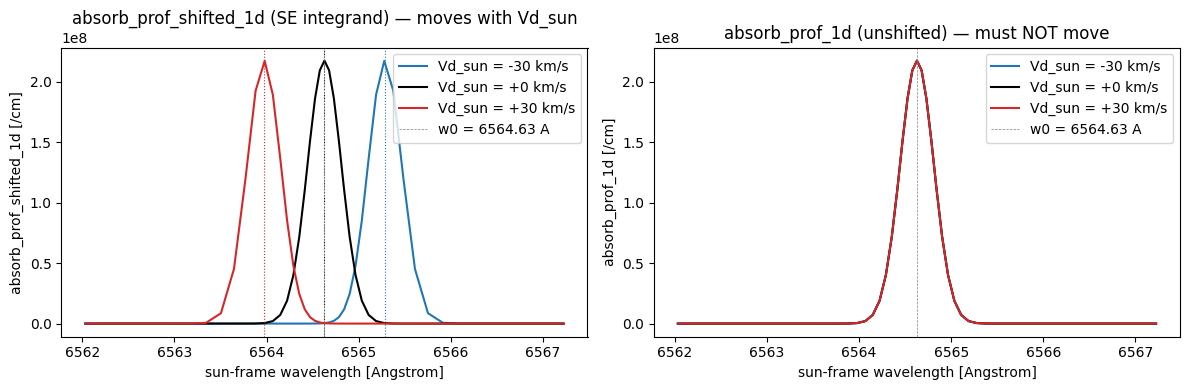

In [2]:
Vd_sun_values = [-3.0e6, 0.0, +3.0e6]  # cm/s, equivalent to -30, 0, +30 km/s

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))

print("Section A — measured peak vs expected (sun-frame, H-alpha):")
for v, c in zip(Vd_sun_values, COLORS):
    SE_con, _ = run(Vd_sun=v, Vd_obs=0.0)
    wl_AA = SE_con.wm_cm_1d[i1:i2] * 1.0e8
    prof_shifted = SE_con.absorb_prof_shifted_1d[i1:i2]

    axL.plot(wl_AA, prof_shifted,
             label=f"Vd_sun = {v / 1.0e5:+.0f} km/s", color=c)
    expected_peak_AA = (w0_cm - w0_cm * v / CST.c_) * 1.0e8
    axL.axvline(expected_peak_AA, color=c, ls=":", lw=0.8)

    measured_peak_AA = float(wl_AA[int(np.argmax(prof_shifted))])
    print(f"  Vd_sun = {v / 1.0e5:+5.0f} km/s  "
          f"expected = {expected_peak_AA:.3f} A  "
          f"measured = {measured_peak_AA:.3f} A")

    axR.plot(wl_AA, SE_con.absorb_prof_1d[i1:i2],
             label=f"Vd_sun = {v / 1.0e5:+.0f} km/s", color=c)

axL.set_title("absorb_prof_shifted_1d (SE integrand) — moves with Vd_sun")
axL.set_xlabel("sun-frame wavelength [Angstrom]")
axL.set_ylabel("absorb_prof_shifted_1d [/cm]")
axL.axvline(w0_cm * 1.0e8, color="gray", ls="--", lw=0.5,
            label=f"w0 = {w0_cm * 1.0e8:.2f} A")
axL.legend()

axR.set_title("absorb_prof_1d (unshifted) — must NOT move")
axR.set_xlabel("sun-frame wavelength [Angstrom]")
axR.set_ylabel("absorb_prof_1d [/cm]")
axR.axvline(w0_cm * 1.0e8, color="gray", ls="--", lw=0.5,
            label=f"w0 = {w0_cm * 1.0e8:.2f} A")
axR.legend()

plt.tight_layout()
plt.show()


**Verification:**

- *Left panel:* the dotted vertical line of each color marks
  $w_0 - w_0 V_{\rm sun}/c$. The shifted profile peak should sit on its
  own dotted line. Positive `Vd_sun` → peak on the blue side.
- *Right panel:* all three curves must overlap exactly. The unshifted
  profile depends only on `(Te, Vt, atom params)`, not on `Vd_sun`.
  Locked numerically by the regression test
  `test_se_absorb_prof_1d_is_unshifted`.


## Section B — `Vd_obs` only

Vary `Vd_obs` with `Vd_sun = 0`. We expect the cloud output's
`tau_1D` peak (plotted against `wl_1D`, which is observer-frame) to sit
at $w_0 + w_0 V_{\rm obs}/c$ — **red** of $w_0$ for $+V_{\rm obs}$
(astronomy radial-velocity convention: positive = recession = red).
SE populations are identical across runs (Vd_sun = 0 in all), so the
peak **amplitudes** should match — only the wavelength labels move.


Section B — measured tau peak vs expected (observer-frame, H-alpha):


  Vd_obs =   -30 km/s  expected = 6563.972 A  measured = 6563.972 A  tau_max  = 3.035e+01
  Vd_obs =    +0 km/s  expected = 6564.629 A  measured = 6564.629 A  tau_max  = 3.035e+01
  Vd_obs =   +30 km/s  expected = 6565.286 A  measured = 6565.286 A  tau_max  = 3.035e+01


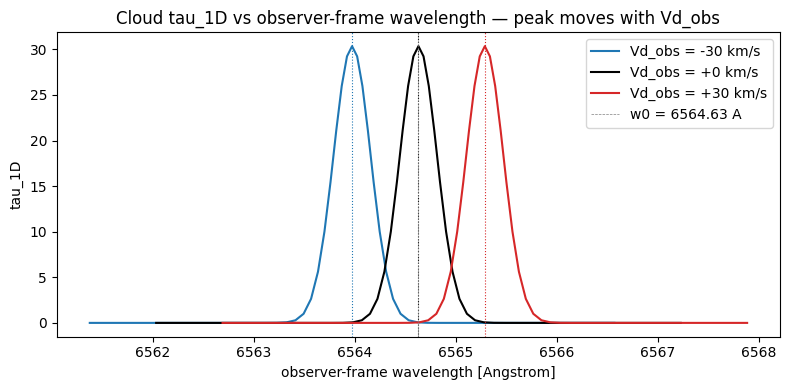

In [3]:
Vd_obs_values = [-3.0e6, 0.0, +3.0e6]  # cm/s

fig, ax = plt.subplots(figsize=(8, 4))

print("Section B — measured tau peak vs expected (observer-frame, H-alpha):")
for v, c in zip(Vd_obs_values, COLORS):
    _, Cloud_con = run(Vd_sun=0.0, Vd_obs=v)
    wl_AA = Cloud_con.wl_1D[i1:i2] * 1.0e8
    tau = Cloud_con.tau_1D[i1:i2]
    ax.plot(wl_AA, tau, label=f"Vd_obs = {v / 1.0e5:+.0f} km/s", color=c)
    expected_peak_AA = (w0_cm + w0_cm * v / CST.c_) * 1.0e8
    ax.axvline(expected_peak_AA, color=c, ls=":", lw=0.8)

    measured_peak_AA = float(wl_AA[int(np.argmax(tau))])
    print(f"  Vd_obs = {v / 1.0e5:+5.0f} km/s  "
          f"expected = {expected_peak_AA:.3f} A  "
          f"measured = {measured_peak_AA:.3f} A  "
          f"tau_max  = {float(tau.max()):.3e}")

ax.set_title("Cloud tau_1D vs observer-frame wavelength — peak moves with Vd_obs")
ax.set_xlabel("observer-frame wavelength [Angstrom]")
ax.set_ylabel("tau_1D")
ax.axvline(w0_cm * 1.0e8, color="gray", ls="--", lw=0.5,
           label=f"w0 = {w0_cm * 1.0e8:.2f} A")
ax.legend()
plt.tight_layout()
plt.show()


**Verification:**

- Each $\tau_{1D}$ peak should sit on the same-colored dotted line at
  $w_0 + w_0 V_{\rm obs}/c$.
- Peak amplitudes should be identical: SE populations don't depend on
  Vd_obs.


## Section C — Both `Vd_sun` and `Vd_obs`

The two velocities act on **independent axes**:

- `Vd_sun` modifies SE populations (via `Jbar`, which integrates the
  sun-shifted profile against `backRad`). It does NOT touch the cloud
  output wavelength labels.
- `Vd_obs` modifies the cloud output wavelength labels. It does NOT
  touch SE.

So with the same `Vd_obs`, varying `Vd_sun` should give the **same
peak position** $w_0 + w_0 V_{\rm obs}/c$ but possibly different
**amplitudes** (populations differ because Jbar differs).


Section C — peak position and amplitude (fixed Vd_obs, varying Vd_sun):
  Vd_sun =    +0  Vd_obs =   +30 km/s  peak = 6565.286 A  tau_max = 3.035e+01
  Vd_sun =   +30  Vd_obs =   +30 km/s  peak = 6565.286 A  tau_max = 3.541e+01
  Vd_sun =   -30  Vd_obs =   +30 km/s  peak = 6565.286 A  tau_max = 3.354e+01


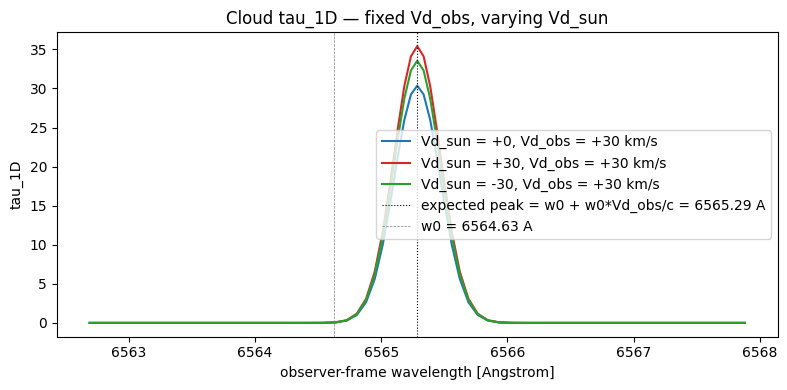

In [4]:
Vd_obs_fixed = +3.0e6  # cm/s; +30 km/s, held constant across cases
cases = [
    (0.0,    Vd_obs_fixed, "C0"),  # only Vd_obs
    (+3.0e6, Vd_obs_fixed, "C3"),  # +Vd_sun, same Vd_obs
    (-3.0e6, Vd_obs_fixed, "C2"),  # -Vd_sun, same Vd_obs
]

fig, ax = plt.subplots(figsize=(8, 4))
print("Section C — peak position and amplitude (fixed Vd_obs, varying Vd_sun):")
for v_sun, v_obs, c in cases:
    _, Cloud_con = run(Vd_sun=v_sun, Vd_obs=v_obs)
    wl_AA = Cloud_con.wl_1D[i1:i2] * 1.0e8
    tau = Cloud_con.tau_1D[i1:i2]
    ax.plot(wl_AA, tau,
            label=(f"Vd_sun = {v_sun / 1.0e5:+.0f}, "
                   f"Vd_obs = {v_obs / 1.0e5:+.0f} km/s"),
            color=c)
    measured_peak_AA = float(wl_AA[int(np.argmax(tau))])
    print(f"  Vd_sun = {v_sun / 1.0e5:+5.0f}  Vd_obs = {v_obs / 1.0e5:+5.0f} km/s  "
          f"peak = {measured_peak_AA:.3f} A  "
          f"tau_max = {float(tau.max()):.3e}")

expected_peak_AA = (w0_cm + w0_cm * Vd_obs_fixed / CST.c_) * 1.0e8
ax.axvline(expected_peak_AA, color="k", ls=":", lw=0.8,
           label=f"expected peak = w0 + w0*Vd_obs/c = {expected_peak_AA:.2f} A")
ax.axvline(w0_cm * 1.0e8, color="gray", ls="--", lw=0.5,
           label=f"w0 = {w0_cm * 1.0e8:.2f} A")
ax.set_title("Cloud tau_1D — fixed Vd_obs, varying Vd_sun")
ax.set_xlabel("observer-frame wavelength [Angstrom]")
ax.set_ylabel("tau_1D")
ax.legend()
plt.tight_layout()
plt.show()


**Verification:**

- All three $\tau_{1D}$ peaks should sit on the same dotted vertical
  line at $w_0 + w_0 V_{\rm obs}/c$ — the wavelength axis depends only
  on `Vd_obs`.
- Peak **amplitudes** may differ between the three curves: `Vd_sun`
  changes the Jbar integrand → changes populations → changes
  $\alpha_0$ → changes $\tau = \alpha_0 \cdot {\rm depth} \cdot
  {\rm absorb\_prof\_1d}$.

This confirms the design contract: **`Vd_sun` lives entirely on the SE
side, `Vd_obs` lives entirely on the cloud-output-mesh side**; they
compose without interference. The cloud model never sees `Vd_sun` and
SE never sees `Vd_obs`.
